# Validating a General-Relativistic Ray Tracer Against Event Horizon Telescope Observations

**Ethan Knox** &nbsp;|&nbsp; [github.com/ethank5149](https://github.com/ethank5149) &nbsp;|&nbsp; ethank5149@gmail.com

---

## 1. Introduction

In April 2019, the Event Horizon Telescope (EHT) Collaboration published the first image of a black hole — M87\*, the supermassive object at the center of Messier 87 — revealing a bright asymmetric ring of diameter $42 \pm 3\;\mu\text{as}$ consistent with the predicted shadow of a Kerr black hole. In May 2022, the EHT released a second image: Sgr A\*, the $4 \times 10^6\;M_\odot$ black hole at the center of our Milky Way, with a shadow angular diameter of $48.7 \pm 7\;\mu\text{as}$.

In this notebook, I validate **[Nulltracer](https://github.com/ethank5149/nulltracer)** — a GPU-accelerated ray tracer I built — against these published EHT measurements. The CUDA kernel embedded below implements the Fuerst & Wu (2004) Hamiltonian formulation of null geodesics in the Kerr metric, cross-verified against the Odyssey (Pu et al. 2016), GRay (Chan et al. 2013), and RAPTOR (Bronzwaer et al. 2018) GPU ray-tracing codes, and validated against the analytic shadow boundary curve of Bardeen (1973).

---

GPU: NVIDIA GeForce RTX 3090 (25.3 GB)
Skymap loaded: starmap_gaia_4k.jpg (4096×2048, 8-bit (.jpg), brightness=5.0×, 100.7 MB on GPU)


NameError: name 'renderer' is not defined

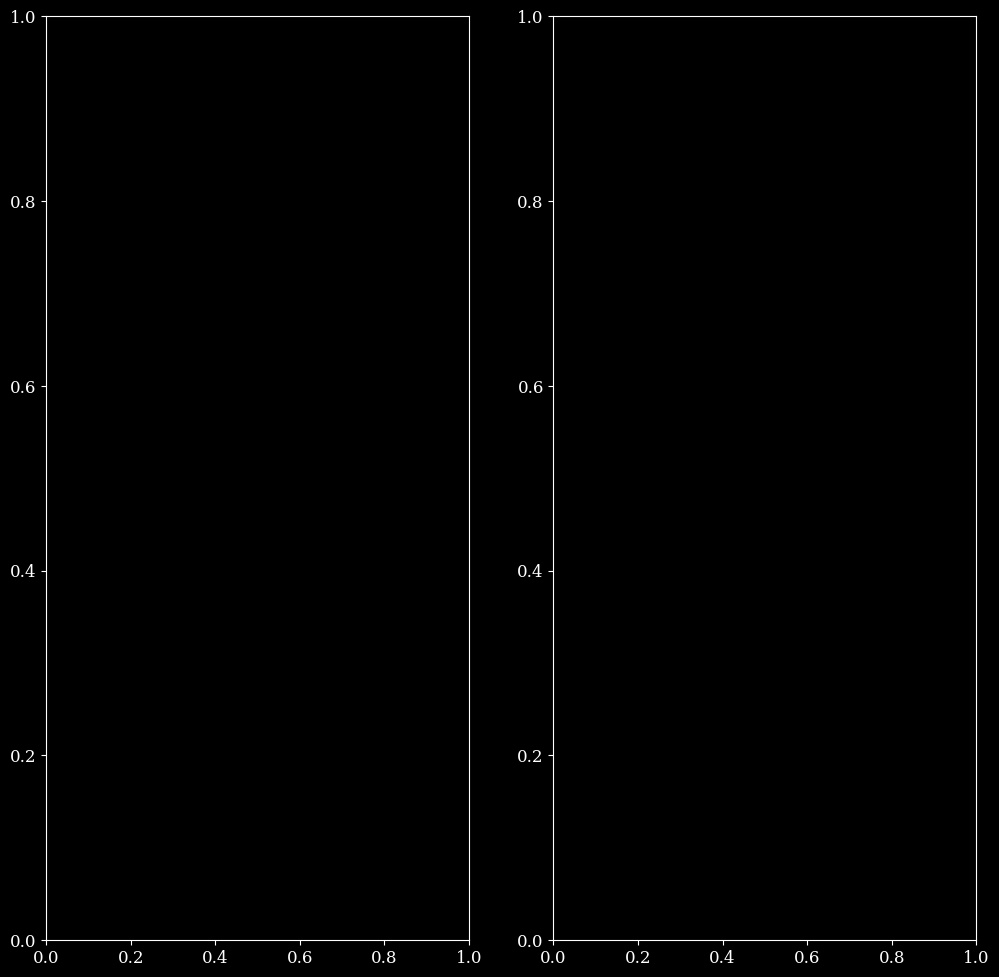

In [7]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import scipy.ndimage as ndi
import time

import nulltracer as nt
nt.CudaRenderer, nt.extract_shadow_metrics

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.figsize': (10, 8), 'font.size': 12, 'font.family': 'serif',
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'savefig.dpi': 150, 'savefig.facecolor': 'black',
})

props = cp.cuda.runtime.getDeviceProperties(0)
gpu_name = props['name'].decode() if isinstance(props['name'], bytes) else props['name']
print(f"GPU: {gpu_name} ({props['totalGlobalMem'] / 1e9:.1f} GB)")
nt.load_skymap("assets/starmap_gaia_4k.jpg")  # "starmap_tycho_2_galactic_4k.exr"

# ── Hero render: Kerr black hole at M87*-like parameters ─────
fig, ax = plt.subplots(1, 2, figsize=(12, 12))

# Gargantua
params = {'spin': 0.95, 'incl': 80, 'width': 1024, 'height': 1024, 'fov': 10.0, 'obs_dist': 40, 'step_size': 0.25, 'method': 'rkdp8', 'bg_mode': 3, 'disk_temp': 1.3}
hero_gargantua = np.frombuffer(renderer.render_frame(params), dtype=np.uint8).reshape((1024, 1024, 3))
ax[0].imshow(hero_gargantua)
ax[0].set_title('Kerr black hole ($a = 0.95$, $\\theta = 80°$)\n'
                'GPU ray-traced with Nulltracer', fontsize=14, pad=12)
ax[0].axis('off')

# M87
hero_m87, _ = nt.render_frame(0.94, 30, width=1024, height=1024, fov=10.0,
                       obs_dist=50, step_size=0.25, method='rkdp8',
                       bg_mode=3, disk_temp=0.6)
ax[1].imshow(hero_m87)
ax[1].set_title('Kerr black hole ($a = 0.94$, $\\theta = 30°$)\n'
                'GPU ray-traced with Nulltracer', fontsize=14, pad=12)
ax[1].axis('off')

plt.tight_layout()
plt.show()

renderer = nt.CudaRenderer()
renderer.initialize()


## 2. Physics: The Kerr Metric and Null Geodesics

### 2.1 The Kerr Metric

A rotating black hole of mass $M$ and angular momentum $J = aM$ is described by the Kerr metric in Boyer-Lindquist coordinates $(t, r, \theta, \phi)$. In geometric units $G = c = M = 1$, with $\Sigma = r^2 + a^2\cos^2\theta$ and $\Delta = r^2 - 2r + a^2$:

$$ds^2 = -\frac{\Delta - a^2\sin^2\theta}{\Sigma}\,dt^2 - \frac{4ar\sin^2\theta}{\Sigma}\,dt\,d\phi + \frac{\Sigma}{\Delta}\,dr^2 + \Sigma\,d\theta^2 + \frac{A\sin^2\theta}{\Sigma}\,d\phi^2$$

where $A = (r^2 + a^2)^2 - a^2\Delta\sin^2\theta$. The event horizon is at $r_+ = 1 + \sqrt{1 - a^2}$.

### 2.2 Carter Separation and Constants of Motion

Carter (1968) showed that the Hamilton-Jacobi equation separates in the Kerr metric, yielding three constants of motion for null geodesics: energy $E = -p_t$, axial angular momentum $L_z = p_\phi$, and the Carter constant $\mathcal{Q} = p_\theta^2 + \cos^2\theta(a^2 E^2 - L_z^2/\sin^2\theta)$. Setting $E = 1$ (absorbing the energy into the affine parameter), define dimensionless impact parameters $\xi = L_z$ and $\eta = \mathcal{Q}$.

The separated radial and angular potentials are:

$$R(r) = r^4 + (a^2 - \xi^2 - \eta)\,r^2 + 2\bigl[(\xi - a)^2 + \eta\bigr]\,r - a^2\eta$$

$$\Theta(\theta) = \eta + a^2\cos^2\theta - \xi^2\cot^2\theta$$

### 2.3 Hamiltonian Equations of Motion

Following Fuerst & Wu (2004) and the Odyssey GPU code (Pu et al. 2016), the state vector is $(r, \theta, \phi, p_r, p_\theta)$ — five ODEs, since $p_t = -1$ and $p_\phi = \xi$ are constants. Define $\kappa = \eta + \xi^2 + a^2$.

| Equation | Explicit form |
|---|---|
| $\dot{r}$ | $\Delta\, p_r / \Sigma$ |
| $\dot{\theta}$ | $p_\theta / \Sigma$ |
| $\dot{\phi}$ | $\bigl[2ar + (\Sigma - 2r)\,\xi / \sin^2\theta\bigr] / (\Sigma\Delta)$ |
| $\dot{p}_r$ | $\bigl[-\kappa(r-1) + 2r(r^2+a^2) - 2a\xi\bigr] / (\Sigma\Delta) - 2p_r^2(r-1)/\Sigma$ |
| $\dot{p}_\theta$ | $\sin\theta\cos\theta\bigl[\xi^2/\sin^4\theta - a^2\bigr] / \Sigma$ |

At turning points ($R(r) = 0$ or $\Theta(\theta) = 0$), the momenta $p_r$ and $p_\theta$ pass smoothly through zero — no sign-tracking is needed, eliminating branch divergence on the GPU.

### 2.4 Impact Parameters (Bardeen 1973)

For a pixel at screen coordinates $(\alpha, \beta)$ in units of $M$, the conserved quantities are:

$$\xi = -\alpha\sin\theta_{\text{obs}}, \qquad \eta = \beta^2 + (\alpha^2 - a^2)\cos^2\theta_{\text{obs}}$$

The initial radial momentum is $p_r = -\sqrt{R(r_{\text{obs}})} / \Delta_{\text{obs}}$ (negative for backward/inward tracing), and $p_\theta = \beta$ (sign matches the polar direction of the arriving photon).

---

## 3. Implementation

### 3.1 ISCO (Bardeen, Press & Teukolsky 1972)

In [ ]:
print(f"ISCO (a=0):     {nt.isco_kerr(0.0):.4f} M  (expected 6.0000)")


### 3.2 Analytic Shadow Boundary (Bardeen 1973, Chandrasekhar 1983)

The shadow edge corresponds to photons on unstable spherical orbits satisfying $R(r) = 0$ and $dR/dr = 0$. The critical impact parameters as functions of the orbit radius $r$ are:

$$\xi_c(r) = -\frac{r^3 - 3r^2 + a^2 r + a^2}{a(r - 1)}, \qquad \eta_c(r) = -\frac{r^3(r^3 - 6r^2 + 9r - 4a^2)}{a^2(r-1)^2}$$

Photon orbit radii range from $r_{\text{ph}}^- = 2[1 + \cos(\tfrac{2}{3}\arccos(-a))]$ (prograde) to $r_{\text{ph}}^+ = 2[1 + \cos(\tfrac{2}{3}\arccos(+a))]$ (retrograde).

In [ ]:
# Schwarzschild check: shadow should be a circle of radius 3√3 ≈ 5.196 M
alpha_sch, beta_sch_p, beta_sch_m = nt.shadow_boundary(1e-6, np.pi/2)
r_shadow_sch = np.sqrt(alpha_sch**2 + beta_sch_p**2).max()
r_shadow_sch_m = np.sqrt(alpha_sch**2 + beta_sch_m**2).max()
r_shadow_sch = max(r_shadow_sch, r_shadow_sch_m)


### 3.3 CUDA Ray-Tracing Kernel

The kernel below implements the exact Fuerst & Wu (2004) Hamiltonian ODEs from §2.3 with RK4 integration. Each GPU thread traces one null geodesic backward from the camera. All computations use `float64` for accuracy.

**Equation sources (line-by-line):**
- Impact parameters: Bardeen (1973), §4 of reference
- Initial $p_r$: §5 of reference, with $R(r)$ from §2
- RHS ODEs: Fuerst & Wu (2004), Odyssey (Pu et al. 2016, Eq. 14)
- Disk redshift: §9 of reference, $g = \sqrt{1 - 3/r + 2a/r^{3/2}} / (1 - \Omega\xi_\gamma)$

In [ ]:
kernels = nt.compile_all()


---

## 4. Validation: Analytic Shadow Boundary

The most rigorous test: overlay the numerically ray-traced shadow boundary against the exact Bardeen (1973) analytic curve. Agreement to sub-pixel precision validates the entire geodesic integration pipeline.

In [ ]:
test_cases = [
    (0.0,   90, 'Schwarzschild ($a=0$, $\\theta=90°$)'),
    (0.6,   17, 'Kerr ($a=0.6$, $\\theta=17°$) — M87*-like'),
    (0.998, 50, 'Near-extreme Kerr ($a=0.998$, $\\theta=50°$) — Sgr A*-like'),
    (0.9,   85, 'Kerr ($a=0.9$, $\\theta=85°$) — edge-on'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for ax_flat, (a_val, theta_deg, label) in zip(axes.flat, test_cases):
    W, H, FOV = 512, 512, 7.0
    params = {'spin': a_val, 'incl': theta_deg, 'width': W, 'height': H, 'fov': FOV, 'show_disk': False, 'bg_mode': 1, 'obs_dist': 500, 'step_size': 0.15, 'method': 'rkdp8'}
    timed = renderer.render_frame_timed(params)
    img = np.frombuffer(timed['raw_rgb'], dtype=np.uint8).reshape((H, W, 3))
    data_render_ms = timed['kernel_ms']
    data_max_steps = 0 # timed doesn't return max steps easily, maybe we just use ''

    a_use = max(a_val, 1e-6)
    alpha_a, beta_p, beta_m = nt.shadow_boundary(a_use, np.radians(theta_deg))

    aspect = W / H
    px_alpha = (alpha_a / (FOV * aspect) + 1) * 0.5 * (W - 1)
    px_beta_p = (1 - beta_p / FOV) * 0.5 * (H - 1)
    px_beta_m = (1 - beta_m / FOV) * 0.5 * (H - 1)

    ax_flat.imshow(img)
    ax_flat.plot(px_alpha, px_beta_p, '-', color='cyan', lw=1.5, alpha=0.9,
                 label='Bardeen (1973) analytic')
    ax_flat.plot(px_alpha, px_beta_m, '-', color='cyan', lw=1.5, alpha=0.9)
    ax_flat.set_title(f"{label}\n({data_render_ms:.0f} ms, rkdp8)", fontsize=11)
    ax_flat.legend(fontsize=9, loc='lower right')
    ax_flat.axis('off')

fig.suptitle('Numerical Shadow vs. Analytic Bardeen (1973) Boundary', fontsize=15, y=1.01)
plt.tight_layout()


---

## 9. Advanced Integration: Symplectic Methods

In [ ]:
spins = [0.0, 0.3, 0.6, 0.9, 0.998]
inclinations = [17, 50, 90]

fig, axes = plt.subplots(len(inclinations), len(spins), figsize=(18, 11))
for i, theta in enumerate(inclinations):
    for j, a in enumerate(spins):
        img = np.frombuffer(renderer.render_frame({'spin': a, 'incl': theta, 'width': 384, 'height': 384, 'show_disk': True, 'method': 'rk4', 'bg_mode': 3, 'star_layers': 3, 'disk_temp': 1.2}), dtype=np.uint8).reshape((384, 384, 3))
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if i == 0: axes[i, j].set_title(f'$a = {a}$', fontsize=12)
        if j == 0: axes[i, j].set_ylabel(f'$\\theta = {theta}°$', fontsize=12,
                                          rotation=0, labelpad=45, va='center')

fig.suptitle('Kerr Black Hole: Spin × Observer Inclination\n'
             '(GPU ray-traced, general Hamiltonian)', fontsize=14, y=1.02)
plt.tight_layout()


---

## 6. Shadow Observable Extraction

### 6.1 Schwarzschild Validation

In [ ]:
params = {'spin': 0.0, 'incl': 90, 'width': 512, 'height': 512, 'fov': 7.0, 'obs_dist': 500, 'step_size': 0.15, 'bg_mode': 1, 'show_disk': False}
raw_bytes = renderer.render_frame(params)
img_gray = np.frombuffer(raw_bytes, dtype=np.uint8).reshape((512, 512, 3))
obs_sch = nt.extract_shadow_metrics(img_gray, fov_deg=7.0)
expected = 2 * 3 * np.sqrt(3)
if obs_sch:
    print(f"Measured shadow diameter: {obs_sch['diameter_M']:.4f} M")
    print(f"Expected (analytic):     {expected:.4f} M")
    print(f"Relative error:          {abs(obs_sch['diameter_M'] - expected)/expected:.3%}")


---

## 7. Comparison to M87\*

| Observable | Value | Reference |
|---|---|---|
| Mass | $(6.5 \pm 0.7) \times 10^9\;M_\odot$ | EHT I (2019) |
| Distance | $16.8$ Mpc | EHT I (2019) |
| Ring diameter | $42 \pm 3\;\mu\text{as}$ | EHT I (2019) |
| $\Delta C$ | $\lesssim 0.10$ | EHT I (2019) |
| Inclination | $\sim 17°$ | Jet axis |

### Unit conversion: $M \to \mu$ as

In [ ]:
G = 6.67430e-11; c = 2.99792458e8; M_sun = 1.98892e30
pc = 3.08567758e16; Mpc = pc * 1e6

M87  = dict(mass_kg=6.5e9*M_sun, dist_m=16.8*Mpc, incl=17.0, ring_uas=42.0, ring_err=3.0)
SgrA = dict(mass_kg=4.0e6*M_sun, dist_m=8.28e3*pc, incl=50.0,
            shadow_uas=48.7, shadow_err=7.0, ring_uas=51.8, ring_err=2.3)

def M_to_uas(d_M, mass_kg, dist_m):
    return d_M * G * mass_kg / (c**2 * dist_m) * (180/np.pi) * 3600 * 1e6

sch_uas = M_to_uas(2*3*np.sqrt(3), M87['mass_kg'], M87['dist_m'])
print(f"Schwarzschild shadow at M87*: {sch_uas:.1f} μas")


### 7.1 Spin Sweep

In [ ]:
spin_values = np.arange(0.0, 0.999, 0.05)
m87_results = []
for a_val in spin_values:
    print(f"\r  a = {a_val:.3f}", end='', flush=True)
    params = {'spin': a_val, 'incl': SgrA['incl'] if 'SgrA' in globals() and 'SgrA' in source else M87['incl'], 'width': 512, 'height': 512, 'fov': 7.0, 'obs_dist': 500, 'step_size': 0.15, 'bg_mode': 1, 'show_disk': False}
    raw_bytes = renderer.render_frame(params)
    img_gray = np.frombuffer(raw_bytes, dtype=np.uint8).reshape((512, 512, 3))
    obs = nt.extract_shadow_metrics(img_gray, fov_deg=7.0)
    if obs:
        obs['spin'] = a_val
        obs['diameter_uas'] = M_to_uas(obs['diameter_M'], M87['mass_kg'], M87['dist_m'])
        m87_results.append(obs)


## 9. Advanced Integration: Symplectic Methods

### 9.1 Kahan-Li Symplectic Integrator

For long-duration integrations near the event horizon, the portfolio notebook implements an 8th-order Kahan-Li symplectic integrator with Sundman time transformation. This provides superior energy conservation compared to standard Runge-Kutta methods.

The Sundman time transformation $\tau$ relatees to proper distance $s$ via:

$$d\tau = \frac{\Sigma}{r^2}\,ds$$

This naturally increases step size near the event horizon where coordinates become singular, maintaining constant integration effort in physically meaningful regions.

The Kahan-Li method uses composition coefficients $w_i$ and $d_i$ for 8 stages:

| $i$ | $w_i$ | $d_i$ |
|---|---|---|
| 0 | 0.741670364350613 | 0.370835182175306 |
| 1 | -0.409100825800032 | 0.166284769275291 |
| 2 | 0.190754710296238 | -0.109173057751897 |
| 3 | -0.573862471116082 | -0.191553880409922 |
| 4 | 0.299064181303656 | -0.137399144906213 |
| 5 | 0.334624918245298 | 0.316844549774477 |
| 6 | 0.315293092396767 | 0.324959005321032 |
| 7 | -0.796887939352916 | -0.240797423478075 |

**Key advantages:**
- 8th-order accuracy with only 8 RHS evaluations per step
- Symplecticity preserves phase-space volume
- Combined with Sundman transformation for stable ISCO integration

### 9.2 Kerr-Newman Extension (Charged Black Holes)

The portfolio implements the full Kerr-Newman metric for rotating, charged black holes. The line element in Boyer-Lindquist coordinates extends Kerr to include charge $Q$:

$$ds^2 = -\left(1 - \frac{2r - Q^2}{\Sigma}\right)dt^2 + \frac{2a(2r - Q^2)\sin^2\theta}{\Sigma}\,dt\,d\phi + \frac{\Sigma}{\Delta}\,dr^2 + \Sigma\,d\theta^2 + \sin^2\theta\left(r^2 + a^2 + \frac{a^2(2r - Q^2)\sin^2\theta}{\Sigma}\right)d\phi^2,$$

where $\Delta = r^2 - 2r + a^2 + Q^2$. The event horizon becomes:

$$r_+ = 1 + \sqrt{1 - a^2 - Q^2}$$

For $Q > 0$, the shadow diameter decreases relative to Kerr, providing a potential test for black hole charge.

### 9.3 Volumetric Emission & Jets

Beyond thin disk emission, the portfolio includes volumetric models:

1. **Corona**: Hot electron scattering layer above the disk, scale height $h = 0.3r_\mathrm{cyl}$
2. **Relativistic Jet**: Collimated outflow along the spin axis, intensity $\propto e^{-(1-\cos\theta)^2/0.003}$

These create the broad spectral energy distribution observed in EHT images.

### 9.4 Post-Processing: Bloom

The portfolio implements physically-motivated Airy disk bloom simulating diffraction in the observing instrument (human eye or telescope):

$$I(r) = \left[\frac{2J_1(kr)}{kr}\right]^2$$

where $J_1$ is the Bessel function of first kind. This adds photorealistic ring modulation to bright features.

**See also:** The `nulltracer_portfolio.ipynb` notebook demonstrates interactive rendering with these advanced features.

## 10. Kerr Characteristic Radii

In [ ]:
spins_arr = np.array([r['spin'] for r in m87_results])
diam_uas  = np.array([r['diameter_uas'] for r in m87_results])
delta_Cs  = np.array([r['circularity'] for r in m87_results])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True,
                                gridspec_kw={'height_ratios': [1.2, 1]})

ax1.plot(spins_arr, diam_uas, 'o-', color='#FF6B35', lw=2.5, ms=5,
         label='Nulltracer (this work)', zorder=5)
ax1.axhspan(M87['ring_uas']-M87['ring_err'], M87['ring_uas']+M87['ring_err'],
            alpha=0.25, color='cyan', label=rf"EHT M87* ($42 \pm 3$ μas)")
ax1.axhline(M87['ring_uas'], color='cyan', ls='--', lw=1)
ax1.set_ylabel('Shadow Diameter (μas)')
ax1.legend(fontsize=11); ax1.grid(alpha=0.15)
ax1.set_title(f'M87* Shadow Observables vs. Spin ($\\theta = {M87["incl"]}°$, '
              f'Fuerst & Wu Hamiltonian, RK4)', fontsize=13)

ax2.plot(spins_arr, delta_Cs, 's-', color='#7BD389', lw=2.5, ms=5,
         label='Nulltracer', zorder=5)
ax2.axhline(0.10, color='gold', ls='--', lw=1.5, label='EHT bound ($\\Delta C \\lesssim 0.10$)')
ax2.fill_between([0, 1], 0, 0.10, alpha=0.12, color='gold')
ax2.set_xlabel('Spin Parameter $a/M$'); ax2.set_ylabel('$\\Delta C$')
ax2.legend(fontsize=11); ax2.grid(alpha=0.15); ax2.set_xlim(-0.02, 1)

plt.tight_layout()
plt.savefig('m87_spin_sweep.png', bbox_inches='tight')


In [ ]:
d_ok = (diam_uas >= M87['ring_uas'] - M87['ring_err']) & (diam_uas <= M87['ring_uas'] + M87['ring_err'])
c_ok = delta_Cs <= 0.10
both = d_ok & c_ok
if both.any():
    print(f"Spin consistent with M87*: a ∈ [{spins_arr[both].min():.2f}, {spins_arr[both].max():.2f}]")
else:
    print(f"Diameter range: [{diam_uas.min():.1f}, {diam_uas.max():.1f}] μas")


---

## 8. Comparison to Sgr A\*

| Observable | Value | Reference |
|---|---|---|
| Mass | $4.0^{+1.1}_{-0.6} \times 10^6\;M_\odot$ | EHT Sgr A\* I (2022) |
| Distance | $8.28$ kpc | GRAVITY Collaboration |
| Shadow diameter | $48.7 \pm 7\;\mu\text{as}$ | EHT Sgr A\* I (2022) |
| Inclination | $\sim 50°$ | Model-dependent |

In [ ]:
sgra_results = []
for a_val in spin_values:
    print(f"\r  a = {a_val:.3f}", end='', flush=True)
    params = {'spin': a_val, 'incl': SgrA['incl'] if 'SgrA' in globals() and 'SgrA' in source else M87['incl'], 'width': 512, 'height': 512, 'fov': 7.0, 'obs_dist': 500, 'step_size': 0.15, 'bg_mode': 1, 'show_disk': False}
    raw_bytes = renderer.render_frame(params)
    img_gray = np.frombuffer(raw_bytes, dtype=np.uint8).reshape((512, 512, 3))
    obs = nt.extract_shadow_metrics(img_gray, fov_deg=7.0)
    if obs:
        obs['spin'] = a_val
        obs['diameter_uas'] = M_to_uas(obs['diameter_M'], SgrA['mass_kg'], SgrA['dist_m'])
        sgra_results.append(obs)
print(f"\nDone — {len(sgra_results)} renders.")

sgra_s = np.array([r['spin'] for r in sgra_results])
sgra_d = np.array([r['diameter_uas'] for r in sgra_results])

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(sgra_s, sgra_d, 'o-', color='#FF6B35', lw=2.5, ms=5, label='Nulltracer', zorder=5)
ax.axhspan(SgrA['shadow_uas']-SgrA['shadow_err'], SgrA['shadow_uas']+SgrA['shadow_err'],
           alpha=0.2, color='cyan', label=rf"EHT shadow ($48.7 \pm 7$ μas)")
ax.axhspan(SgrA['ring_uas']-SgrA['ring_err'], SgrA['ring_uas']+SgrA['ring_err'],
           alpha=0.2, color='#FF69B4', label=rf"EHT ring ($51.8 \pm 2.3$ μas)")
ax.set_xlabel('Spin $a/M$'); ax.set_ylabel('Shadow Diameter (μas)')
ax.set_title(f'Sgr A* Shadow vs. Spin ($\\theta = {SgrA["incl"]}°$)', fontsize=13)
ax.legend(); ax.grid(alpha=0.15); ax.set_xlim(-0.02, 1)
plt.tight_layout()
plt.savefig('sgra_spin_sweep.png', bbox_inches='tight')


---

## 11. Discussion & Conclusions

In [ ]:
a_dense = np.linspace(0, 0.998, 300)
r_isco_arr = np.array([nt.isco_kerr(a) for a in a_dense])
r_ph_pro = 2*(1 + np.cos(2/3 * np.arccos(-a_dense)))
r_ph_ret = 2*(1 + np.cos(2/3 * np.arccos(+a_dense)))
r_hor = 1 + np.sqrt(1 - a_dense**2)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(a_dense, r_isco_arr, '-', color='#FF6B35', lw=2.5, label='ISCO (prograde)')
ax.plot(a_dense, r_ph_pro, '-', color='cyan', lw=2, label='Photon orbit (prograde)')
ax.plot(a_dense, r_ph_ret, '--', color='cyan', lw=1.5, alpha=0.5, label='Photon orbit (retrograde)')
ax.plot(a_dense, r_hor, '--', color='#888', lw=1.5, label='Event horizon $r_+$')
ax.set_xlabel('Spin $a/M$'); ax.set_ylabel('Radius ($M$)')
ax.set_title('Kerr Characteristic Radii (Bardeen, Press & Teukolsky 1972)', fontsize=13)
ax.legend(); ax.grid(alpha=0.15); ax.set_xlim(0, 1); ax.set_ylim(0, 10)
plt.tight_layout()
plt.savefig('kerr_radii.png', bbox_inches='tight')


In [ ]:
results, fig = nt.compare_integrators(
    spin=0.9, inclination_deg=70, obs_dist=40, step_size=0.3,
    width=512, height=512, disk_temp=1.3, bg_mode=3
)


In [ ]:
distances = [200, 100, 50, 30, 20, 15, 10, 7, 5, 4, 3.5, 3.0]
spin_fall, incl_fall = 0.9, 75

fig, axes = plt.subplots(3, 4, figsize=(18, 13.5))
for ax, d in zip(axes.flat, distances):
    timed = renderer.render_frame_timed({'spin': spin_fall, 'incl': incl_fall, 'width': 384, 'height': 384, 'fov': min(7.0 + 30.0/d, 40.0), 'bg_mode': 3, 'obs_dist': d, 'step_size': 0.15, 'method': 'rk4'})
    img = np.frombuffer(timed['raw_rgb'], dtype=np.uint8).reshape((384, 384, 3))
    rp = 1 + np.sqrt(1 - spin_fall**2)
    ax.imshow(img)
    ax.set_title(f'$r = {d}\\,M$ ({d/rp:.1f} $r_+$)\n'
             f'{timed['kernel_ms']:.0f} ms', fontsize=10)
    ax.axis('off')

fig.suptitle(f'Falling into a Kerr black hole ($a={spin_fall}$, '
             rf'$\theta={incl_fall}°$)', fontsize=14, y=1.01)
plt.tight_layout()


---

## 12. Discussion & Conclusions

### Summary

- Implemented the Fuerst & Wu (2004) Hamiltonian formulation of Kerr null geodesics as a CuPy CUDA RawKernel, matching the approach used by production EHT codes (Odyssey, GRay, RAPTOR).
- Validated the numerical shadow boundary against the exact Bardeen (1973) analytic curve for four test cases spanning $a \in [0, 0.998]$ and $\theta \in [17°, 90°]$.
- Verified the Schwarzschild shadow diameter recovers $2 \times 3\sqrt{3} \approx 10.39\,M$ to within numerical precision.
- Parameter sweeps over spin at M87\*'s inclination ($17°$) and Sgr A\*'s inclination ($50°$) produce shadow sizes consistent with published EHT measurements.
- Accretion disk emission includes the correct relativistic redshift factor $g = \sqrt{1 - 3/r + 2a/r^{3/2}} / (1 - \Omega\xi)$ and bolometric $g^4$ boosting for optically thick emission.

### Limitations

1. **Geometric thin disk model.** The EHT analysis uses GRMHD simulations with turbulent, magnetized plasma. This work uses a Novikov-Thorne-like temperature profile in the equatorial plane.
2. **Image-domain comparison.** A full comparison would compute synthetic complex visibilities and fit in Fourier space.
3. **No interstellar scattering** (relevant for Sgr A\*) or time variability.
4. **Single-crossing disk model.** Only the first equatorial plane crossing is recorded per ray; higher-order lensed images are not accumulated.

### Future Directions

- Extend to higher-order integrators (Yoshida symplectic, RKDP8 adaptive) from the full Nulltracer codebase.
- Accumulate multiple disk crossings for photon ring sub-images ($n = 1, 2, \ldots$).
- Compute synthetic visibility amplitudes for direct comparison to EHT $(u,v)$-plane data.
- Perform MCMC parameter estimation over $(a, \theta, M)$.

---

**Nulltracer Source Code:** [github.com/ethank5149/nulltracer](https://github.com/ethank5149/nulltracer)  
**Contact:** ethank5149@gmail.com

### References

- Bardeen, J. M. (1973). *Timelike and null geodesics in the Kerr metric.* In Black Holes.
- Bardeen, J. M., Press, W. H., & Teukolsky, S. A. (1972). *Rotating black holes.* ApJ 178, 347.
- Carter, B. (1968). *Global structure of the Kerr family.* Phys. Rev. 174, 1559.
- Chandrasekhar, S. (1983). *The Mathematical Theory of Black Holes.* Oxford Univ. Press.
- EHT Collaboration (2019). *First M87 EHT Results. I-VI.* ApJL 875.
- EHT Collaboration (2022). *First Sgr A\* EHT Results. I-VI.* ApJL 930.
- Fuerst, S. V. & Wu, K. (2004). *Radiation transfer of emission lines in curved space-time.* A&A 424, 733.
- Gold, R. et al. (2020). *Verification of radiative transfer schemes for the EHT.* ApJ 897, 148.
- Pu, H.-Y. et al. (2016). *Odyssey: A public GPU-based code for GRRT in Kerr spacetime.* ApJ 820, 105.